In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.decomposition import PCA

In [2]:
df = pd.read_csv('../../data/cholestrol.csv', index_col=0)
df

,age,bp,cholesterol,bmi,sleep,triglyceride,fbs,crp,homocysteine
0,56.0,153.0,155.0,24.991591,7.633228,342.0,120.8,12.969246,12.387250
1,69.0,146.0,286.0,25.221799,8.744034,133.0,157.0,9.355389,19.298875
2,46.0,126.0,216.0,29.855447,4.440440,393.0,92.0,12.709873,11.230926
3,32.0,122.0,293.0,24.130477,5.249405,293.0,94.0,12.509046,5.961958
4,60.0,166.0,242.0,20.486289,7.030971,263.0,154.0,10.381259,8.153887
...,...,...,...,...,...,...,...,...,...
9995,25.0,136.0,243.0,18.788791,6.834954,343.0,133.0,3.588814,19.132004
9996,38.0,172.0,154.0,31.856801,8.247784,377.0,83.0,2.658267,9.715709
9997,73.0,152.0,201.0,26.899911,4.436762,248.0,88.0,4.408867,9.492429
9998,23.0,142.0,299.0,34.964026,8.526329,113.0,153.0,7.215634,11.873486


In [4]:
X = df.drop(columns=['cholesterol'])
y = df['cholesterol']

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, shuffle=True, random_state=42)

In [9]:
pca = PCA(n_components=2)
pca.fit(X_train)
pca

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",2
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized SVD 

In [31]:
pca_xy = pca.transform(X_train)
pca_x, pca_y = pca_xy[:, 0], pca_xy[:, 1]

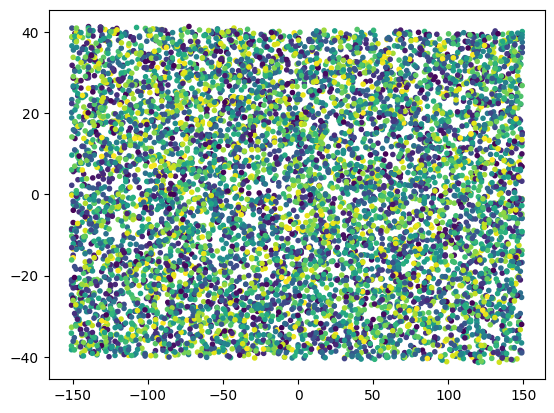

In [32]:
plt.scatter(pca_x, pca_y, c=y_train, marker='.')

In [33]:
points = 512

pca_x = np.linspace(pca_x.min(), pca_x.max(), points)
pca_y = np.linspace(pca_y.min(), pca_y.max(), points)

xx, yy = np.meshgrid(pca_x, pca_y)
mesh_points = np.c_[xx.ravel(), yy.ravel()]
inverted_data = pca.inverse_transform(mesh_points)

In [44]:
import tensorflow as tf
from tensorflow.keras import layers, models

In [51]:
model = models.Sequential([
    layers.Dense(32, activation='leaky_relu', input_shape=(X_train.shape[1],)),
    layers.Dense(X_train.shape[1])
])

model.compile(optimizer='adam', loss='mae', metrics=['r2_score'])
model.fit(X_train, X_train, epochs=100, batch_size=32, verbose=1)

Epoch 1/100


/home/osbox/miniconda3/envs/learning/lib/python3.13/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 21.8425 - r2_score: -20.2017
Epoch 2/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 5.2631 - r2_score: 0.1925 
Epoch 3/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 1.9404 - r2_score: 0.7603
Epoch 4/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.7609 - r2_score: 0.8933
Epoch 5/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.5050 - r2_score: 0.9351
Epoch 6/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.4134 - r2_score: 0.9547
Epoch 7/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3691 - r2_score: 0.9644
Epoch 8/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3749 - r2_score: 0.9755
Epoch 9/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3283 - r2_score: 0.9838
Epoch 10/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3038 - r2_score: 0.9883
Epoch 11/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.2999 - r2_score: 0.9930
Epoch 12/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/

In [64]:
weights = model.get_weights()
np.save(file='encoder_weights', arr=weights[0])
np.save(file='encoder_bias', arr=weights[1])
np.save(file='decoder_weights', arr=weights[2])
np.save(file='decoder_bias', arr=weights[3])

def encode(X):
    return (X @ weights[0]) + weights[1]

def decode(X):
    return (X @ weights[2]) + weights[3]

In [73]:
from lightgbm import LGBMRegressor

lgm_model = LGBMRegressor(
    n_estimators=1000, 
    learning_rate=0.01,
    num_leaves=31,
    objective='regression',
    metric='mae',
    n_jobs=-1
)
lgm_model.fit(encode(X_train), y_train)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.013022 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 8160
[LightGBM] [Info] Number of data points in the train set: 8000, number of used features: 32
[LightGBM] [Info] Start training from score 225.278200


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.01
,n_estimators,1000
,subsample_for_bin,200000
,objective,'regression'
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [74]:
from sklearn.metrics import (
    mean_absolute_error,
    r2_score
)
y_pred = lgm_model.predict(encode(X_test))

print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

MAE: 37.966019432571194
R2 Score: -0.03024424212778376


In [35]:
inverted_pred = rf_model.predict(inverted_data)
inverted_pred

/home/osbox/miniconda3/envs/learning/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


array([216.54, 214.6 , 214.6 , ..., 225.15, 225.15, 225.48],
      shape=(262144,))

In [37]:
prediction_surface = inverted_pred.reshape(points, points)

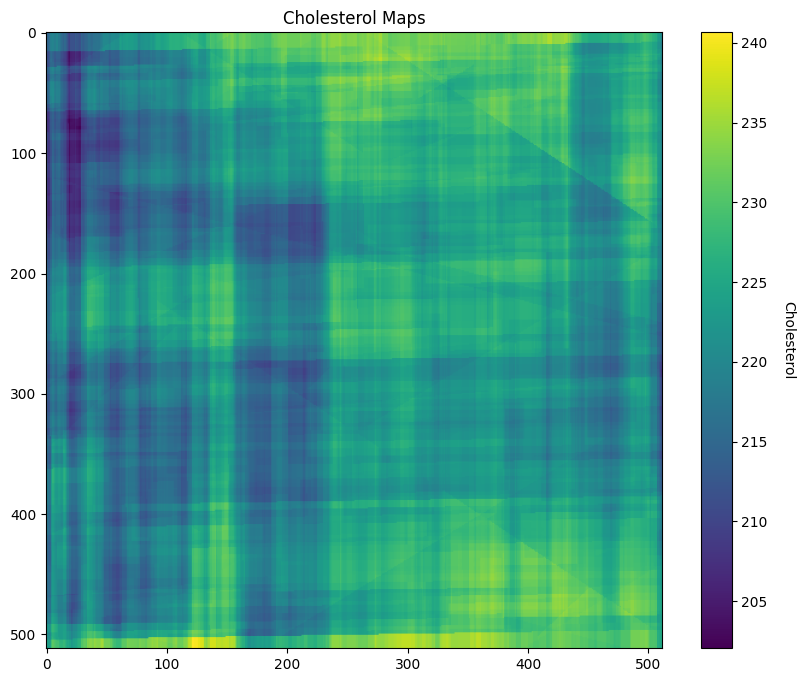

In [39]:
plt.figure(figsize=(10, 8))
plt.imshow(
    prediction_surface,
    cmap='viridis'
) 

cbar = plt.colorbar()
cbar.set_label('Cholesterol', rotation=270, labelpad=20)
plt.title('Cholesterol Maps')
plt.show()